In [1]:
%run -i ./04_statistically_independent_uncorrelated.ipynb
%matplotlib widget

Often we have estimated a PDF for some random variable and then want to quantify how certain we are in, for example, the mean of that PDF. One method of doing this is to look at the *entropy* or *Shannon information*, $H$, which is given by

$$H(\mathbf{x}) = -E[\ln p(\mathbf{x})] = -\int p(\mathbf{x}) \ln p(\mathbf{x}) \, d\mathbf{x}. \tag{2.21}$$

We will make this expression specific to Gaussian PDFs shortly.


In [26]:
@write_method(_ContinuousRandomEvent)
def entropy(self):
  surprise = _ContinuousRandomEvent(
    f=(lambda *args: (
      math.log(p) if (p := self.p(*args)) > 0 else 0.0
    )),
    p=self.p,
    bounds=self.bounds
  )
  return surprise.expectation() * -1

1.0000
1.4189


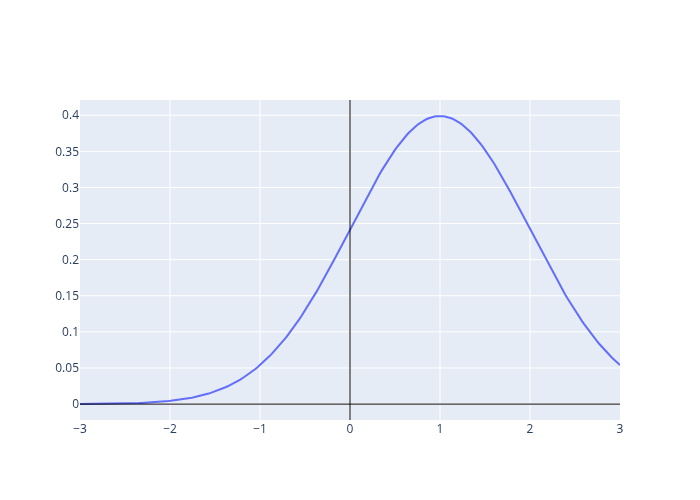

In [27]:
if __name__ == '__main__' and '__file__' not in globals():
  a = _ContinuousRandomEvent(f=_ContinuousFunction(),
                                p=_ContinuousFunction(_gaussian(1.0, 1.0)),
                                bounds=[(-128.0, 128.0)])
  print(f'{a.expectation():.4f}')
  print(f'{a.entropy():.4f}')
  _plot_function(a.p, (-3.0, 3.0))

2.8379


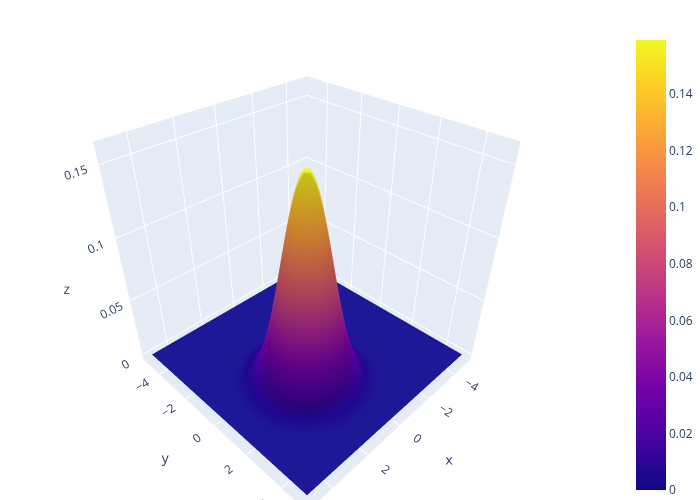

In [28]:
if __name__ == '__main__' and '__file__' not in globals():
  F = _ContinuousFunction(
    f=(lambda x, y: ([x, y])), 
    bounds=[(-128.0, 128.0), (-128.0, 128.0)])
  p = _ContinuousFunction(f=(lambda x, y: (
    _gaussian(1.0, 1.0)(x) * _gaussian(1.0, 1.0)(y)
  )), bounds=[(-128.0, 128.0), (-128.0, 128.0)])

  something = _ContinuousRandomEvent(
    f=F, p=p, bounds=[(-128.0, 128.0), (-128.0, 128.0)])
  print(f'{something.entropy():.4f}')
  _plot_surface(something.p)

Another useful quantity is the *mutual information*, $I(\mathbf{x}, \mathbf{y})$, between two random variables, $\mathbf{x}$ and $\mathbf{y}$, given by

$$I(\mathbf{x}, \mathbf{y}) = E \left[ \ln \left( \frac{p(\mathbf{x}, \mathbf{y})}{p(\mathbf{x})p(\mathbf{y})} \right) \right] = \iint p(\mathbf{x}, \mathbf{y}) \ln \left( \frac{p(\mathbf{x}, \mathbf{y})}{p(\mathbf{x})p(\mathbf{y})} \right) \, d\mathbf{x} \, d\mathbf{y}. \tag{2.22}$$

Mutual information measures how much knowing one of the variables reduces uncertainty about the other. When $\mathbf{x}$ and $\mathbf{y}$ are statistically independent, we have

$$I(\mathbf{x}, \mathbf{y}) = \iint p(\mathbf{x}) p(\mathbf{y}) \ln \left( \frac{p(\mathbf{x})p(\mathbf{y})}{p(\mathbf{x})p(\mathbf{y})} \right) d\mathbf{x} \, d\mathbf{y} = \iint p(\mathbf{x}) p(\mathbf{y}) \underbrace{\ln(1)}_{0} \, d\mathbf{x} \, d\mathbf{y} = 0. \tag{2.23}$$

When $\mathbf{x}$ and $\mathbf{y}$ are dependent, we have $I(\mathbf{x}, \mathbf{y}) \ge 0$.


In [ ]:
if __name__ == '__main__' and '__file__' not in globals():
  px_from_pxy = _ContinuousFunction(
    # p(x)
    f=(lambda x: (
      # ∫ p(x, y) dy
      _ContinuousFunction(
        f=(lambda y: (
          pxy(x, y)
        )), bounds=[(-128.0, 128.0)]
      ).integrate()
    )), bounds = [(-128.0, 128.0)]
  )  
  _plot_function(px_from_pxy)

  py_from_pxy = _ContinuousFunction(
    # p(y)
    f=(lambda y: (
      # ∫ p(x, y) dx
      _ContinuousFunction(
        f=(lambda x: (
          pxy(x, y)
        )), bounds=[(-128.0, 128.0)]
      ).integrate()
    )), bounds=[(-128.0, 128.0)]
  )
  _plot_function(py_from_pxy)

In [ ]:
# @write_method(_ContinuousRandomEvent)
# def marginalize(self, keep=None):
#   if keep == 'x':
#     px_from_pxy = _ContinuousFunction(
#       f=(lambda x: (
#         _ContinuousFunction(
#           f=(lambda y: (
#             self.p(x, y)
#           )), bounds=self.bounds
#         ).integrate()
#       )), bounds=self.bounds
#     )
#     return _ContinuousRandomEvent(
#       f=self.
#     )

In [ ]:
# @write_method(_ContinuousRandomEvent)
# def entropy(self):
#   surprise = _ContinuousRandomEvent(
#     f=(lambda *args: (
#       math.log(p) if (p := self.p(*args)) > 0 else 0.0
#     )),
#     p=self.p,
#     bounds=self.bounds
#   )
#   return surprise.expectation() * -1

In [ ]:
# @write_method(_ContinuousRandomEvent)
# def mutual_information(self):
#   assert len(self.bounds) == 2, 'topmost matrix should split in 2'
#   foo = _ContinuousRandomEvent(
#     f=(lambda *args: )
#   )
#   return foo.expectation()

When $\mathbf{x}$ and $\mathbf{y}$ are dependent, we have $I(\mathbf{x}, \mathbf{y}) \ge 0$. We also have the useful relationship

$$I(\mathbf{x}, \mathbf{y}) = H(\mathbf{x}) + H(\mathbf{y}) - H(\mathbf{x}, \mathbf{y}), \tag{2.24}$$

relating mutual information and Shannon information.
